In [1]:
import pandas as pd
df = pd.read_excel('1688640705_hr_comma_sep.xlsx')

In [2]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
import pandas as pd
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 14999
Number of columns: 10


In [ ]:
# 1 Perform data quality check by checking for missing values if any.

In [4]:
import pandas as pd
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


In [6]:
#2 Understand what factors contributed most to employee turnover by EDA.


In [7]:
#2.1 Draw a heatmap of the Correlation Matrix between all numerical features/columns in the data.

/var/folders/t5/0nsbwlcs17732cg4y_6c7g6h0000gn/T/ipykernel_49409/2937035611.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


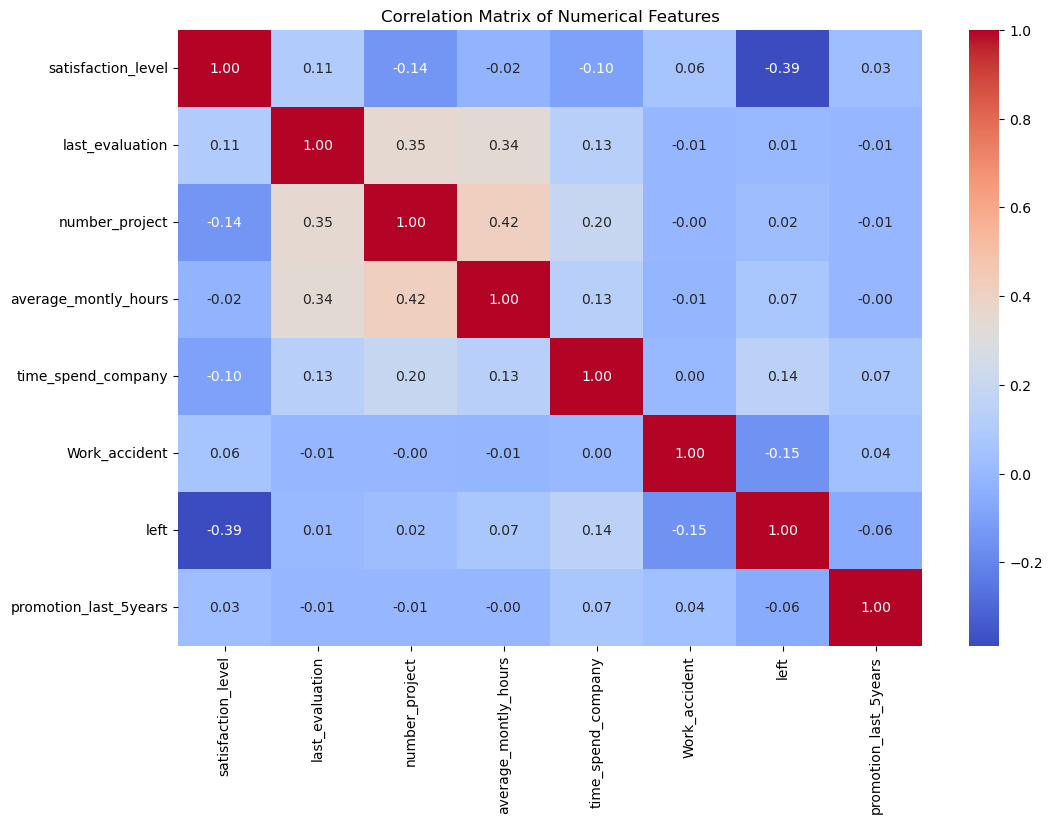

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr() 

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


In [ ]:
# 2.2 Draw the distribution plot of - Employee Satisfaction (use column satisfaction_level), Employee Evaluation (use column last_evaluation), Employee Average Monthly Hours (use column average_montly_hours)

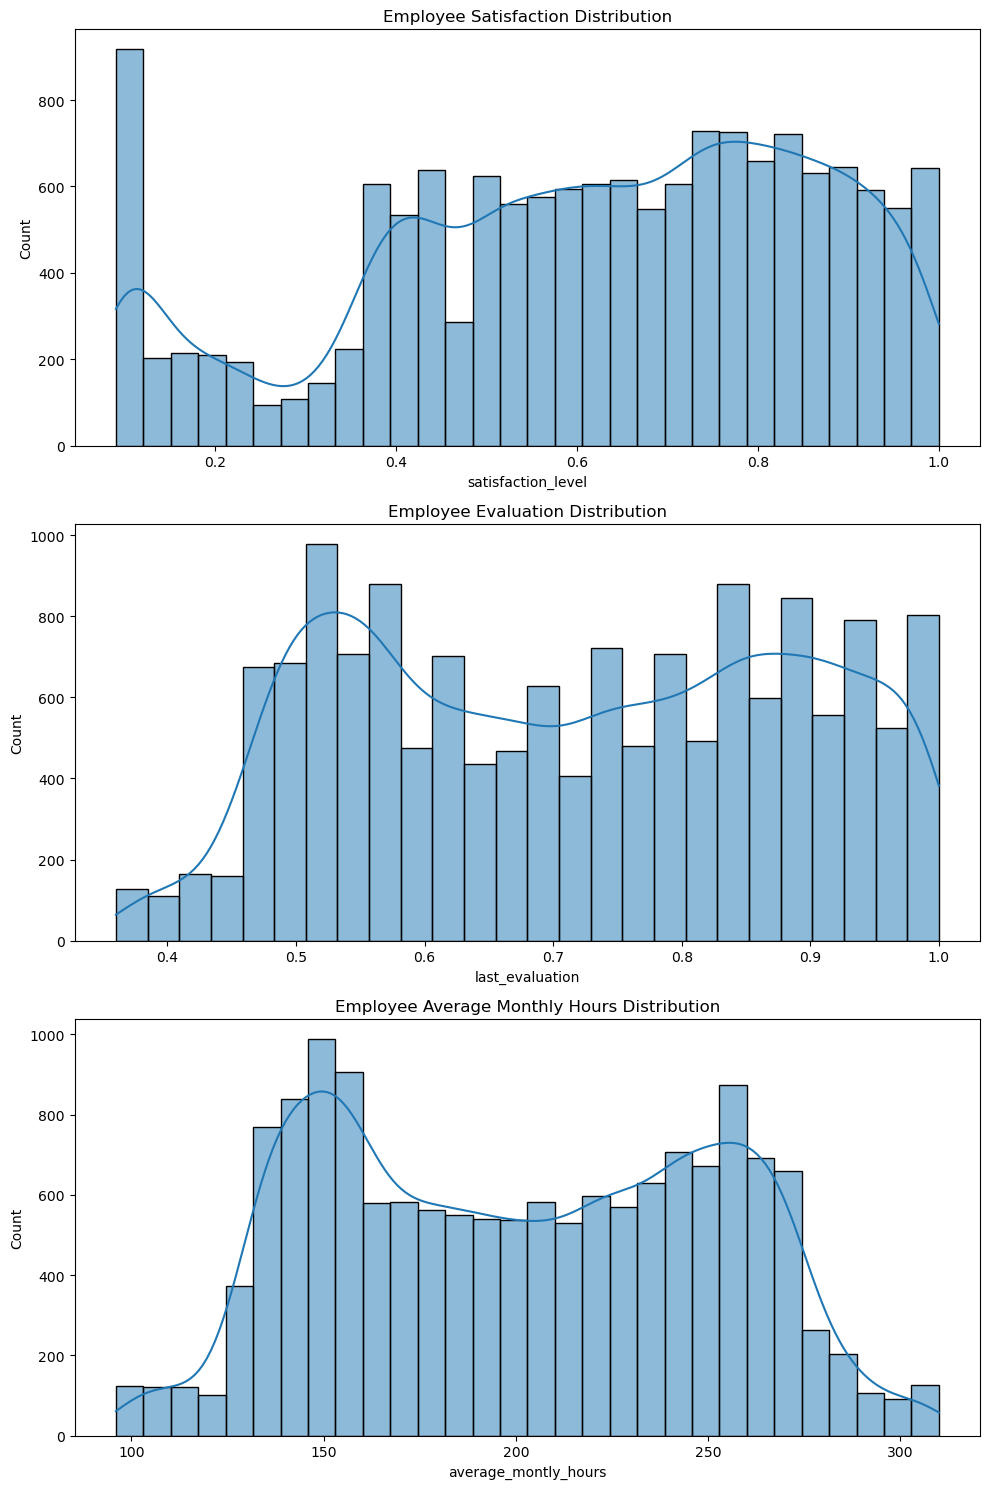

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(10, 15))

sns.histplot(df['satisfaction_level'], kde=True, ax=axs[0])
axs[0].set_title('Employee Satisfaction Distribution')

sns.histplot(df['last_evaluation'], kde=True, ax=axs[1])
axs[1].set_title('Employee Evaluation Distribution')

sns.histplot(df['average_montly_hours'], kde=True, ax=axs[2])
axs[2].set_title('Employee Average Monthly Hours Distribution')

plt.tight_layout()
plt.show()


In [ ]:
#2.3 Draw the bar plot of Employee Project Count of both employees who left and who stayed in the organization (use column number_project and hue column left)  and give your inferences from the plot.

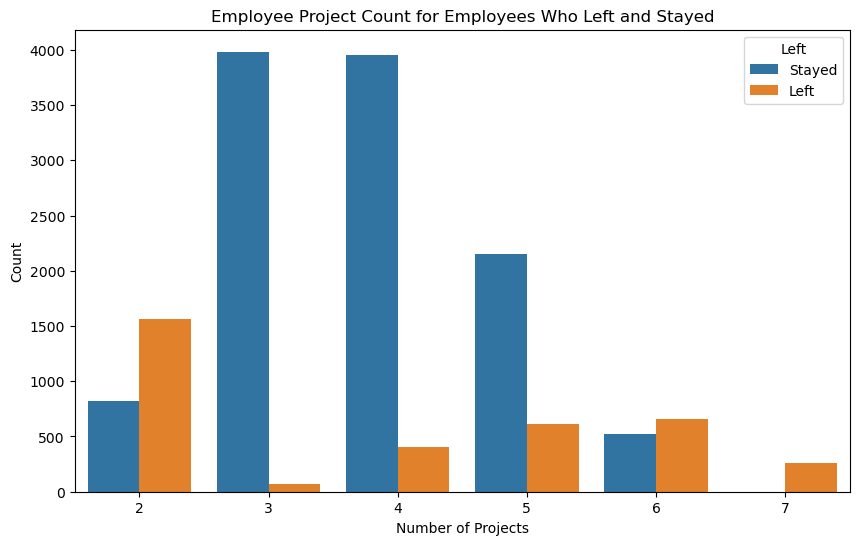

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Employee Project Count for Employees Who Left and Stayed')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.legend(title='Left', loc='upper right', labels=['Stayed', 'Left'])
plt.show()


In [11]:
# Inferences 
# Employees with 2 projects are more likely to leave the organization compared to those with 3, 4, 5, 6, or 7 projects.
# Employees with 7 projects are least likely to leave, followed by those with 3 or 5 projects.
# The number of projects seems to have an impact on employee retention, with a higher number of projects potentially indicating more engagement or job satisfaction.

In [12]:
#3 Perform clustering of Employees who left based on their satisfaction and evaluation.

In [ ]:
#3.1 Choose columns satisfaction_level, last_evaluation and left.
#3.2 Do KMeans clustering of employees who left the company into 3 clusters.

/Users/eshaanyadav/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


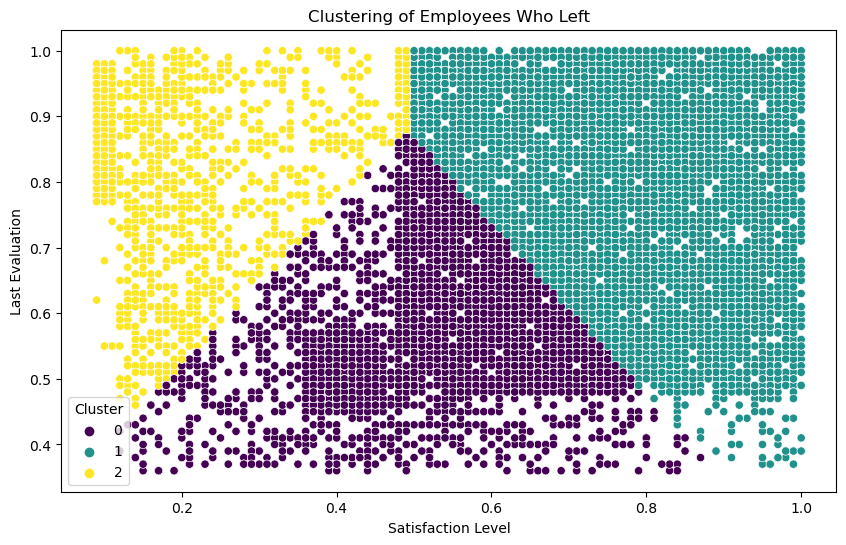

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data = df[['satisfaction_level', 'last_evaluation', 'left']]

kmeans = KMeans(n_clusters=3, random_state=0).fit(data[['satisfaction_level', 'last_evaluation']])
df['cluster'] = kmeans.labels_

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='satisfaction_level', y='last_evaluation', hue='cluster', palette='viridis')
plt.title('Clustering of Employees Who Left')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Cluster')
plt.show()

In [15]:
#3.3 Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

# Cluster 0: This cluster represents employees with low satisfaction and low evaluation. These employees might have been dissatisfied with their work and performance, leading to their decision to leave.
#Cluster 1: This cluster represents employees with high satisfaction and low evaluation. These employees might have felt unappreciated or undervalued despite being satisfied with their work, which could have contributed to their decision to leave.
#Cluster 2: This cluster represents employees with moderate satisfaction and high evaluation. These employees might have been seeking better opportunities or challenges, leading them to leave despite being relatively satisfied with their current role.
#These are general interpretations, and the actual reasons for leaving can vary based on individual circumstances.

In [ ]:
#4 Handle the left Class Imbalance using SMOTE technique.
#4.1 Pre-Process the data by converting categorical columns to numerical columns by -Separating categorical variables and numeric variables, Applying get_dummies() to the categorical variables, Combining categorical variables and numeric variables.
#4.2 Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.
#4.3 Upsample the train dataset using SMOTE technique from the imblearn module.

In [16]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

categorical_cols = ['sales', 'salary']
numeric_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']

categorical_data = pd.get_dummies(df[categorical_cols])

processed_data = pd.concat([df[numeric_cols], categorical_data], axis=1)

y = df['left']

X_train, X_test, y_train, y_test = train_test_split(processed_data, y, test_size=0.2, random_state=123, stratify=y)

smote = SMOTE(random_state=123)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_smote:", X_train_smote.shape)
print("Shape of y_train_smote:", y_train_smote.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train_smote: (18284, 20)
Shape of y_train_smote: (18284,)
Shape of X_test: (3000, 20)
Shape of y_test: (3000,)


In [26]:
#5 Perform 5-Fold cross-validation model training and evaluate performance. 
#5.1 Train a Logistic Regression model and apply a 5-Fold CV and plot the classification report.
#5.2 Train a Random Forest Classifier model and apply the 5-Fold CV and plot the classification report.
#5.3 Train a  Gradient Boosting Classifier model and apply the 5-Fold CV and plot the classification report.

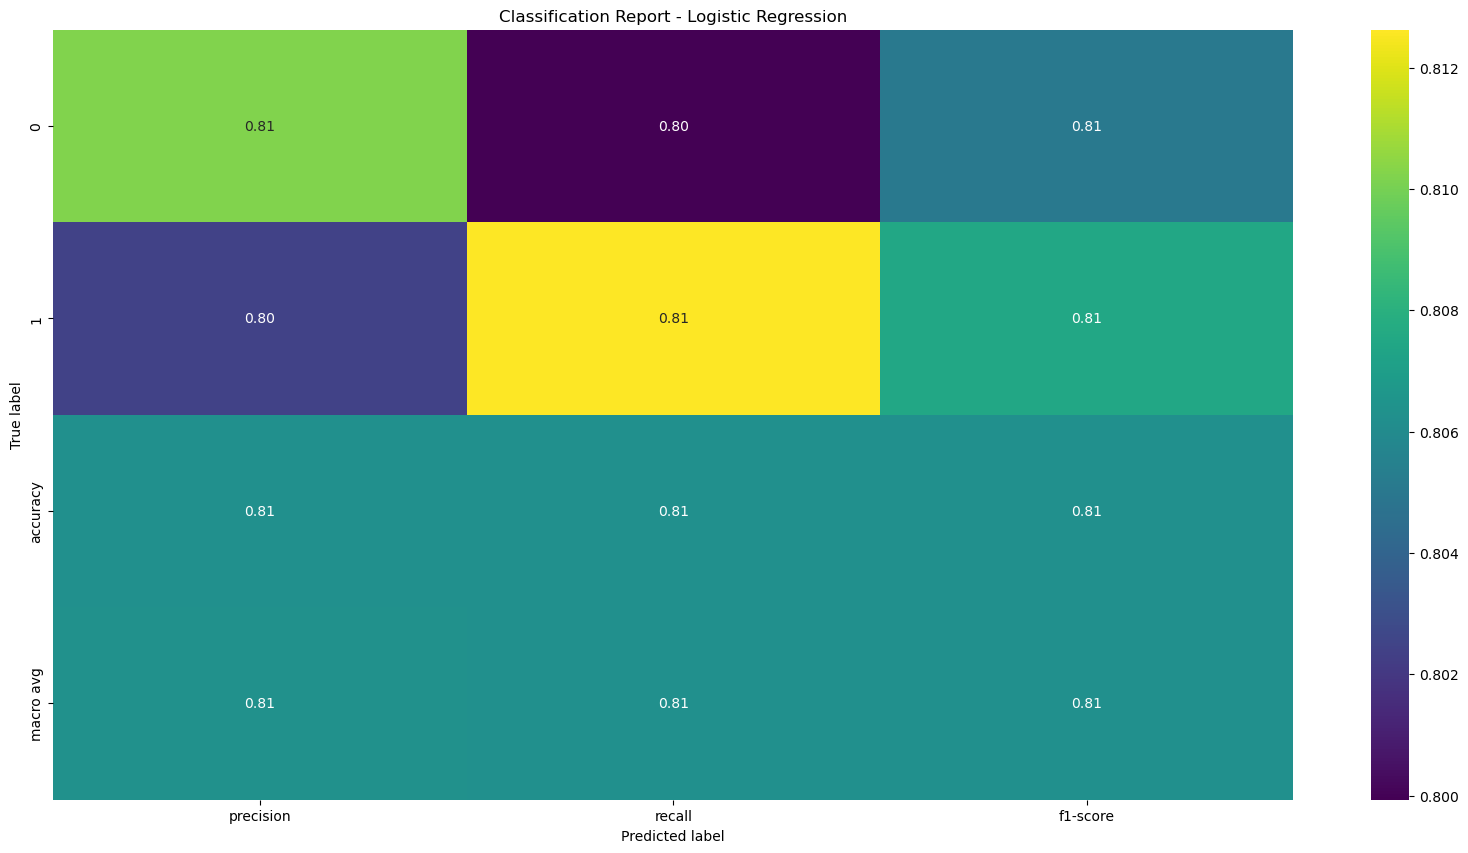

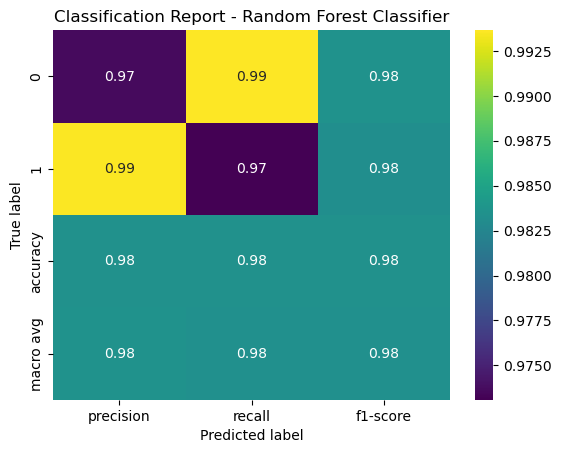

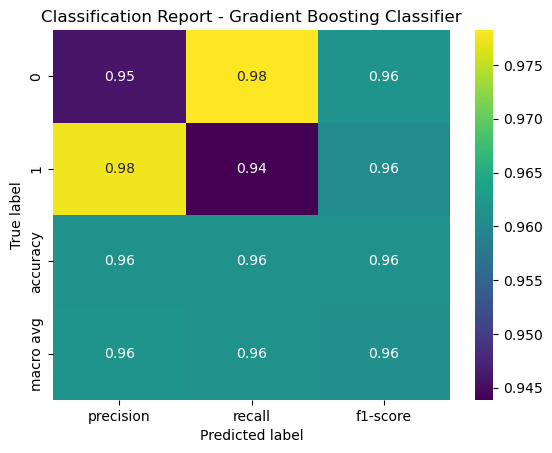

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier()
}

plt.figure(figsize=(20, 10))
for clf_name, clf in classifiers.items():
    y_pred = cross_val_predict(clf, X_train_smote_scaled, y_train_smote, cv=5)
    report = classification_report(y_train_smote, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap='viridis', fmt='.2f')
    plt.title(f"Classification Report - {clf_name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

    

In [ ]:
#6 Identify the best model and justify the evaluation metrics used. 
#6.1 Find the ROC/AUC for each model and plot the ROC curve.
#6.2 Find the confusion matrix for each of the models.
#6.3 From the confusion matrix, explain which metric needs to be used- Recall or Precision

Evaluation Metrics:
Accuracy Scores: {'Logistic Regression': 0.7813333333333333, 'Random Forest Classifier': 0.9866666666666667, 'Gradient Boosting Classifier': 0.9656666666666667}
Precision Scores: {'Logistic Regression': 0.5303983228511531, 'Random Forest Classifier': 0.9667590027700831, 'Gradient Boosting Classifier': 0.9225449515905948}
Recall Scores: {'Logistic Regression': 0.7086834733893558, 'Random Forest Classifier': 0.9775910364145658, 'Gradient Boosting Classifier': 0.9341736694677871}
F1 Scores: {'Logistic Regression': 0.6067146282973622, 'Random Forest Classifier': 0.9721448467966574, 'Gradient Boosting Classifier': 0.9283228949199722}
ROC AUC Scores: {'Logistic Regression': 0.8202749166158152, 'Random Forest Classifier': 0.9945800279866979, 'Gradient Boosting Classifier': 0.9858645120340348}


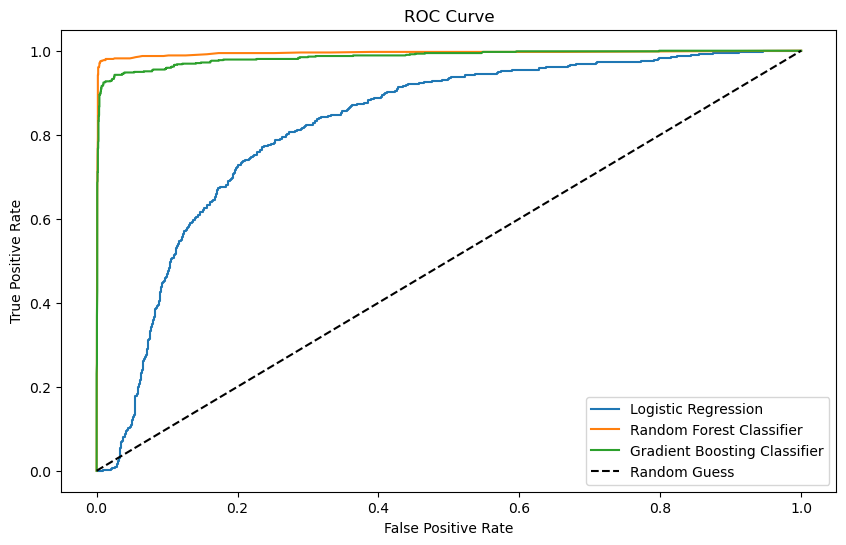

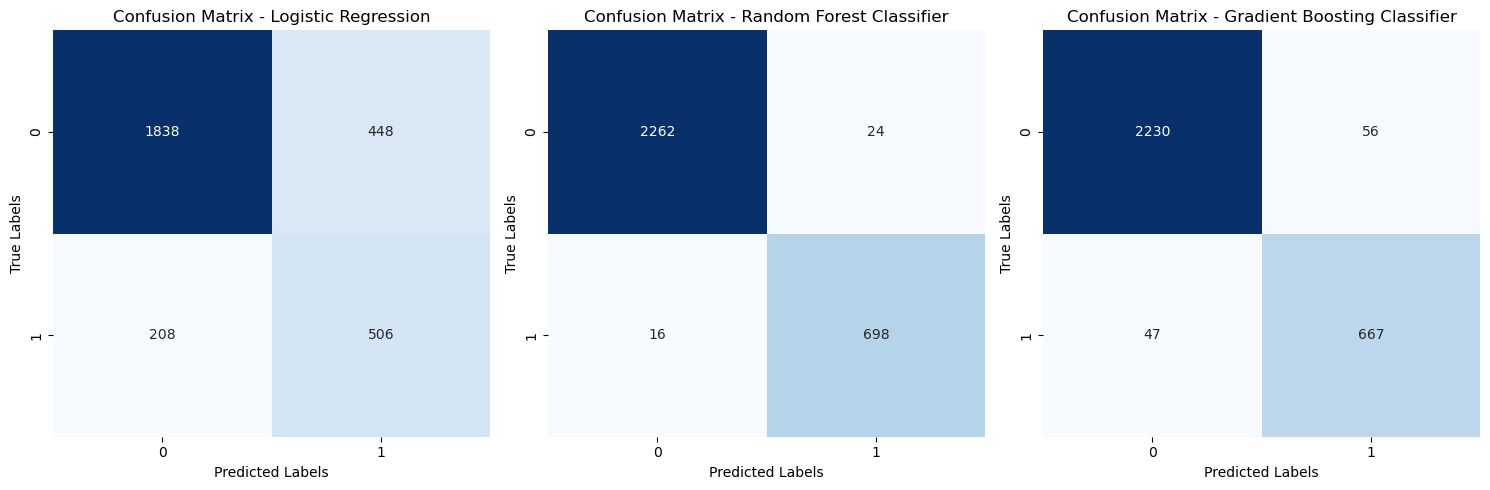

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

accuracy_scores = {}
precision_scores = {}
recall_scores = {}
f1_scores = {}
roc_auc_scores = {}
conf_matrices = {}

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier()
}

for clf_name, clf in classifiers.items():
 
clf.fit(X_train_smote_scaled, y_train_smote)
      
        y_pred = clf.predict(X_test_scaled)

        accuracy_scores[clf_name] = clf.score(X_test_scaled, y_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision_scores[clf_name] = report['1']['precision']
    recall_scores[clf_name] = report['1']['recall']
    f1_scores[clf_name] = report['1']['f1-score']

    y_prob = clf.predict_proba(X_test_scaled)[:,1]
    roc_auc_scores[clf_name] = roc_auc_score(y_test, y_prob)

    conf_matrices[clf_name] = confusion_matrix(y_test, y_pred)


    print("Evaluation Metrics:")
print("Accuracy Scores:", accuracy_scores)
print("Precision Scores:", precision_scores)
print("Recall Scores:", recall_scores)
print("F1 Scores:", f1_scores)
print("ROC AUC Scores:", roc_auc_scores)


plt.figure(figsize=(10, 6))
for clf_name, clf in classifiers.items():
    y_prob = clf.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=clf_name)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


plt.figure(figsize=(15, 5))
for i, (clf_name, conf_matrix) in enumerate(conf_matrices.items()):
    plt.subplot(1, 3, i+1)
    sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.title(f'Confusion Matrix - {clf_name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

# Explanation on whether to use Recall or Precision based on confusion matrix
# If the cost of false positives is high, then we should prioritize Precision.
# If the cost of false negatives is high, then we should prioritize Recall.


In [ ]:
#7 Suggest various retention strategies for targeted employees.
#7.1 Using the best model, predict the probability of employee turnover in the test data.
#7.2 Based on the below probability score range, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.
# Safe Zone (Green) (Score < 20%)
# Low Risk Zone (Yellow) (20% < Score < 60%)
# Medium Risk Zone (Orange) (60% < Score < 90%)
# High Risk Zone (Red) (Score > 90%).

In [22]:
from sklearn.ensemble import RandomForestClassifier


rf_classifier = RandomForestClassifier()


rf_classifier.fit(X_train_smote_scaled, y_train_smote)


y_pred_proba_rf = rf_classifier.predict_proba(X_test_scaled)[:, 1]


print("Predicted Probabilities of Employee Turnover using Random Forest Classifier:")
print(y_pred_proba_rf)


Predicted Probabilities of Employee Turnover using Random Forest Classifier:
[0.   0.67 0.14 ... 0.02 0.02 0.99]


In [25]:
import numpy as np



results_df = pd.DataFrame({
    'Probability Score': y_pred_proba_rf
})


results_df['Zone'] = results_df['Probability Score'].apply(categorize_employee_zone)


results_df['Employee ID'] = np.arange(1, len(results_df) + 1)


print(results_df)


print("\nRetention Strategies:")
for zone in results_df['Zone'].unique():
    employees_in_zone = results_df[results_df['Zone'] == zone]
    print(f"\n{zone}:")
    for employee_id in employees_in_zone['Employee ID']:
        print(f"Employee ID: {employee_id} - Retention Strategy: <Insert Strategy>")


      Probability Score                       Zone  Employee ID
0                  0.00          Safe Zone (Green)            1
1                  0.67  Medium Risk Zone (Orange)            2
2                  0.14          Safe Zone (Green)            3
3                  0.00          Safe Zone (Green)            4
4                  0.05          Safe Zone (Green)            5
...                 ...                        ...          ...
2995               0.00          Safe Zone (Green)         2996
2996               0.02          Safe Zone (Green)         2997
2997               0.02          Safe Zone (Green)         2998
2998               0.02          Safe Zone (Green)         2999
2999               0.99       High Risk Zone (Red)         3000

[3000 rows x 3 columns]

Retention Strategies:

Safe Zone (Green):
Employee ID: 1 - Retention Strategy: <Insert Strategy>
Employee ID: 3 - Retention Strategy: <Insert Strategy>
Employee ID: 4 - Retention Strategy: <Insert Strategy>